In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

seed= 42

In [14]:
def preprocess_data(data):
    df= data.copy()

    df.drop(columns=['SampleID'], inplace= True)

    return df

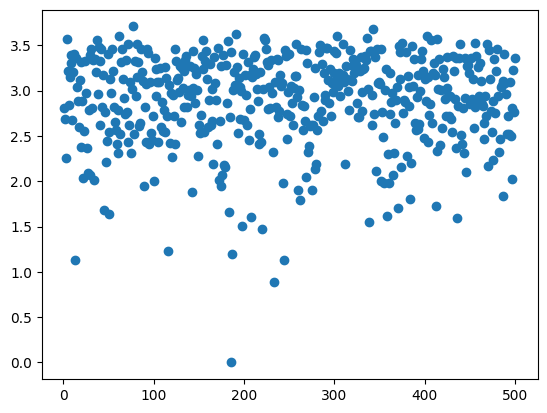

In [15]:
train_df= pd.read_csv("train.csv")
test_df= pd.read_csv("test.csv")

X_train= preprocess_data(train_df.drop(columns=['temperature']))
y_train= np.log1p(train_df['temperature']+abs(train_df['temperature'].min()))

X_test= preprocess_data(test_df)

plt.scatter(train_df['SampleID'], y_train)
plt.show()

In [16]:
from catboost import CatBoostRegressor

model= CatBoostRegressor(
    iterations=3000,
    learning_rate=0.03,
    depth=6,
    early_stopping_rounds=200,
    random_state=seed
)

model.fit(X_train, y_train, verbose= 200)

0:	learn: 0.4936360	total: 28.7ms	remaining: 1m 26s
200:	learn: 0.0948338	total: 177ms	remaining: 2.46s
400:	learn: 0.0563386	total: 311ms	remaining: 2.02s
600:	learn: 0.0406093	total: 437ms	remaining: 1.75s
800:	learn: 0.0301757	total: 562ms	remaining: 1.54s
1000:	learn: 0.0235340	total: 678ms	remaining: 1.35s
1200:	learn: 0.0189467	total: 810ms	remaining: 1.21s
1400:	learn: 0.0154018	total: 938ms	remaining: 1.07s
1600:	learn: 0.0123764	total: 1.07s	remaining: 939ms
1800:	learn: 0.0102673	total: 1.19s	remaining: 794ms
2000:	learn: 0.0085992	total: 1.32s	remaining: 658ms
2200:	learn: 0.0073400	total: 1.43s	remaining: 520ms
2400:	learn: 0.0062424	total: 1.61s	remaining: 402ms
2600:	learn: 0.0052705	total: 1.75s	remaining: 268ms
2800:	learn: 0.0044307	total: 1.87s	remaining: 133ms
2999:	learn: 0.0037136	total: 1.99s	remaining: 0us


CatBoostRegressor(depth=6, early_stopping_rounds=200, iterations=3000, learning_rate=0.03, loss_function='RMSE', random_state=42)

In [20]:
predictions= np.expm1(model.predict(X_test))- abs(train_df['temperature'].min())
answer=pd.DataFrame({
    'SampleID': test_df['SampleID'],
    'temperature': predictions
})

answer.head()

,SampleID,temperature
0,1001,0.949405
1,1002,6.189739
2,1003,17.461412
3,1004,-1.939442
4,1005,6.348277


In [21]:
answer.to_csv("submission.csv", index= False)